# JWM-Read v1 — Kaggle T4 training
Train **our own architecture** (JWM: dual-tower MoT, MoE reasoner, byte tokenizer)
to read Vietnamese text, documents, and OOD scenes.

- 768px input, patch-16 + 2x2 merge -> 576 visual tokens, hierarchical MLP stem
- ~168M total / ~91M active params, batch 16 fp16 fits T4 16GB easily
- Curriculum: A) synthetic words/lines -> B) full synthetic curriculum -> C) 50/50 real doc pages
- Shutdown-safe: checkpoints every 500 steps to `/kaggle/working` — just Run-All again to resume

**Settings needed**: Accelerator = GPU T4 x1, Internet = ON, Persistence = Files.


In [1]:
# 1) Code: clone our repo
import os, sys, subprocess
REPO = '/kaggle/working/mini-world-model'
PUB_URL = 'https://github.com/anhsown/mini-world-model'
if not os.path.exists(REPO):
    subprocess.run(['git', 'clone', '--depth', '1', PUB_URL, REPO], check=True)
else:
    subprocess.run(['git', '-C', REPO, 'remote', 'set-url', 'origin', PUB_URL], check=True)
    subprocess.run(['git', '-C', REPO, 'pull'], check=True)
sys.path.insert(0, REPO)
import torch
print('torch', torch.__version__, '| cuda:', torch.cuda.get_device_name(0))


Cloning into '/kaggle/working/mini-world-model'...


torch 2.10.0+cu128 | cuda: Tesla T4


In [2]:
# 2) Dataset: Vietnamese DocumentImage Reasoning (research license — do not redistribute)
from huggingface_hub import snapshot_download
DATA = '/kaggle/tmp/vdoc'
snapshot_download('trannhiem/TranNhiem-Vietnamese-DocumentImage-Reasoning',
                  repo_type='dataset', local_dir=DATA,
                  allow_patterns=['data/vdoc.jsonl', 'shards/*.tar'], max_workers=4)
print('downloaded')


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloaded


In [3]:
# 3) Extract image tars, then delete tars to save disk (11GB tars + 11GB images)
import os
from jwm.read_data import extract_tars
IMAGES = '/kaggle/tmp/vdoc_images'
extract_tars(f'{DATA}/shards', IMAGES)
for f in os.listdir(f'{DATA}/shards'):
    if f.endswith('.tar'):
        os.remove(f'{DATA}/shards/{f}')
print('extracted; disk:', os.popen('df -h /kaggle/tmp | tail -1').read().strip())


extracting images-00000.tar ...
extracting images-00001.tar ...
extracting images-00002.tar ...
extracting images-00003.tar ...
extracting images-00004.tar ...
extracting images-00005.tar ...
extracted; disk: overlay         7.9T  6.9T  1.1T  87% /


In [4]:
# 4) Data: fonts, corpus, doc pairs, camera model (pinned Jarvis-webcam params), batchers
from jwm.configs import reader_scale
from jwm.read_data import (find_fonts, load_corpus_lines, load_doc_pairs,
                           LazyReadBatcher, PrefetchBatcher, build_eval_set)
from jwm.sdg import CameraParams

cfg = reader_scale()
fonts = find_fonts(); assert fonts, 'no fonts found'
corpus = load_corpus_lines(f'{DATA}/data/vdoc.jsonl')
doc_pairs = load_doc_pairs(f'{DATA}/data/vdoc.jsonl', IMAGES)
cam = CameraParams(noise_std=7.2, blur_sigma=0.54, jpeg_q=55,
                   contrast=1.25, wb_shift=6.0, vignette=0.12)

# held-out doc pairs for eval (never trained on)
eval_pairs, train_pairs = doc_pairs[:400], doc_pairs[400:]
eval_set = build_eval_set(cfg, eval_pairs, fonts, corpus, cam, n_synth_per_level=12, n_doc=60)
print(f'fonts={len(fonts)} corpus={len(corpus)} train_pairs={len(train_pairs)} eval={len(eval_set)}')


doc pairs: kept=21641 skipped_long=300941
fonts=1 corpus=87177 train_pairs=21241 eval=108


In [5]:
# 5) Model + resume state
import json, torch
from jwm.model import JWM

CKPT = '/kaggle/working/jwm_read_ckpt.pt'
device = 'cuda'
model = JWM(cfg)
state = {'stage': 0, 'steps_done': 0}
if os.path.exists(CKPT):
    blob = torch.load(CKPT, map_location='cpu', weights_only=False)
    model.load_state_dict(blob['model'])
    state = blob['state']
    print('RESUMED from', state)
model = model.to(device)
print(f'params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M total')

def save_ckpt(stage, steps_done):
    torch.save({'model': model.state_dict(),
                'state': {'stage': stage, 'steps_done': steps_done},
                'cfg': cfg.__dict__}, CKPT + '.tmp')
    os.replace(CKPT + '.tmp', CKPT)   # atomic — a mid-save kill can't corrupt


params: 167.9M total


In [6]:
# 6) Staged curriculum training (each stage resumable at stage granularity)
from jwm.trainer import train_stage

BATCH = 16
STAGES = [
    # (levels, synth_ratio, steps, lr)  — A: big text only, B: full curriculum, C: real docs enter
    ((1, 2),       1.0, 1500, 3e-4),
    ((1, 2, 3, 4), 1.0, 4000, 3e-4),
    ((1, 2, 3, 4), 0.5, 6000, 1.5e-4),
]
history = []
for si, (levels, ratio, steps, lr) in enumerate(STAGES):
    if state['stage'] > si:
        print(f'stage {si}: already done, skipping'); continue
    remaining = steps - (state['steps_done'] if state['stage'] == si else 0)
    if remaining <= 0:
        state = {'stage': si + 1, 'steps_done': 0}; continue
    print(f'=== stage {si}: levels={levels} synth={ratio} steps={remaining}/{steps} lr={lr} ===')
    inner = LazyReadBatcher(cfg, train_pairs if ratio < 1.0 else [], fonts, corpus, cam,
                            synth_ratio=ratio, levels=levels, seed=1234 + si)
    pf = PrefetchBatcher(inner, BATCH, depth=3)
    base = steps - remaining
    hist = train_stage(model, None, None, cfg, device, steps=remaining, lr=lr,
                       batch_size=BATCH, mode_probs={'qa': 1.0}, warmup=min(200, remaining // 5),
                       log_every=50, ckpt_every=500, batcher=pf,
                       ckpt_fn=lambda done, si=si, base=base: save_ckpt(si, base + done))
    pf.stop()
    history.append((si, hist))
    state = {'stage': si + 1, 'steps_done': 0}
    save_ckpt(si + 1, 0)
print('training complete')


=== stage 0: levels=(1, 2) synth=1.0 steps=1500/1500 lr=0.0003 ===


/kaggle/working/mini-world-model/jwm/model.py:334: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  aux = aux + float(la)


  [    0/1500] mode=qa     loss=23.0654 qa_ce=23.0654 qa_tok_acc=0.0000 moe_aux=0.1165 | 0.5 it/s
  [   50/1500] mode=qa     loss=16.9531 qa_ce=16.9531 qa_tok_acc=0.1381 moe_aux=0.0961 | 0.9 it/s
  [  100/1500] mode=qa     loss=9.9513 qa_ce=9.9513 qa_tok_acc=0.2793 moe_aux=0.0951 | 0.9 it/s
  [  150/1500] mode=qa     loss=9.2258 qa_ce=9.2258 qa_tok_acc=0.2954 moe_aux=0.0923 | 0.8 it/s
  [  200/1500] mode=qa     loss=7.9189 qa_ce=7.9189 qa_tok_acc=0.3775 moe_aux=0.0901 | 0.8 it/s
  [  250/1500] mode=qa     loss=8.3664 qa_ce=8.3664 qa_tok_acc=0.3724 moe_aux=0.0894 | 0.8 it/s
  [  300/1500] mode=qa     loss=5.3222 qa_ce=5.3222 qa_tok_acc=0.4744 moe_aux=0.0873 | 0.8 it/s
  [  350/1500] mode=qa     loss=5.9457 qa_ce=5.9457 qa_tok_acc=0.4779 moe_aux=0.0883 | 0.8 it/s
  [  400/1500] mode=qa     loss=5.7946 qa_ce=5.7946 qa_tok_acc=0.5167 moe_aux=0.0896 | 0.8 it/s
  [  450/1500] mode=qa     loss=5.9976 qa_ce=5.9976 qa_tok_acc=0.5258 moe_aux=0.0881 | 0.8 it/s
  [  500/1500] mode=qa     loss=5.91

In [7]:
# 7) Evaluation: CER + exact-match per curriculum level and on real doc pages
from jwm.trainer import eval_read
res = eval_read(model, eval_set, cfg, device, fonts=fonts, corpus=corpus, cam=cam, batch=8)
json.dump({k: v for k, v in res['per_kind'].items()},
          open('/kaggle/working/metrics_read_v1.json', 'w'), indent=2)
for r in res['rows'][:6]:
    print(f"[{r['kind']}] CER={r['cer']:.2f}\n  ref : {r['ref'][:90]}\n  pred: {r['pred'][:90]}")


  READ doc: CER=0.776 exact=0.00 (n=60)
  READ synthL1: CER=29.891 exact=0.00 (n=12)
  READ synthL2: CER=8.348 exact=0.00 (n=12)
  READ synthL3: CER=1.808 exact=0.00 (n=12)
  READ synthL4: CER=0.822 exact=0.00 (n=12)
  READ overall: CER=4.972 exact=0.00
[synthL1] CER=54.33
  ref : thu
  pred: thống trường trình tra trả trình trình trong ảnh, những từ nào được đề cập đến trong ảnh, 
[synthL1] CER=41.00
  ref : Theo
  pred: thống trường trình tra trả trình trình trong ảnh, những từ nào được đề cập đến trong ảnh, 
[synthL1] CER=17.78
  ref : hướng dẫn
  pred: thống trường trình tra trả trình trình trong ảnh, những từ nào được đề cập đến trong ảnh, 
[synthL1] CER=20.12
  ref : tác phẩm
  pred: thống trường trình tra trả trình trình trong ảnh, những từ nào được đề cập đến trong ảnh, 
[synthL1] CER=15.90
  ref : khoa thống
  pred: thống trường trình tra trả trình trình trong ảnh, những từ nào được đề cập đến trong ảnh, 
[synthL1] CER=23.00
  ref : cho một
  pred: thống trường trình tra trả t

saved /kaggle/working/jwm_read_v1.pt


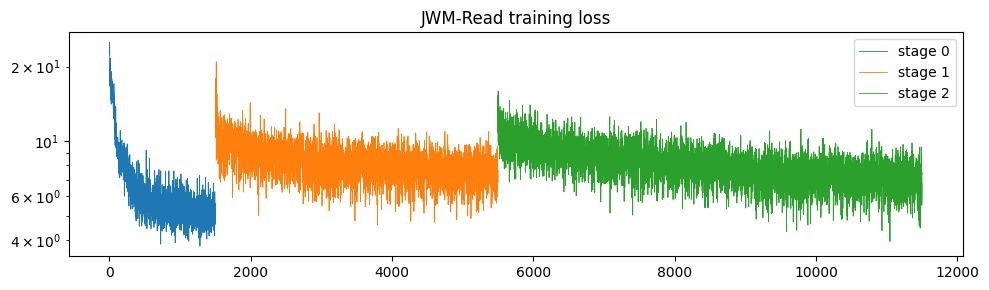

In [8]:
# 8) Final artifact + loss curve
import matplotlib.pyplot as plt
torch.save({'model': model.state_dict(), 'cfg': cfg.__dict__,
            'metrics': res['per_kind']}, '/kaggle/working/jwm_read_v1.pt')
print('saved /kaggle/working/jwm_read_v1.pt')
if history:
    plt.figure(figsize=(10, 3))
    off = 0
    for si, h in history:
        plt.plot([s + off for s in h['step']], h['loss'], lw=0.6, label=f'stage {si}')
        off += len(h['step'])
    plt.yscale('log'); plt.legend(); plt.title('JWM-Read training loss'); plt.tight_layout()
    plt.savefig('/kaggle/working/loss_read_v1.png', dpi=110); plt.show()


## Sau khi chạy xong
Tải về từ **Output** của notebook: `jwm_read_v1.pt`, `metrics_read_v1.json`, `loss_read_v1.png`
— đặt `jwm_read_v1.pt` vào `Jarvis-Vision/` 
